In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# 1️⃣ Conectar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2️⃣ Definir la ruta de tu carpeta Automatidata
ruta_base = '/content/drive/MyDrive/Automatidata'

# 3️⃣ Cargar el dataset desde esa carpeta
import pandas as pd
data_path = f'{ruta_base}/2017_Yellow_Taxi_Trip_Data.csv'
taxi_data = pd.read_csv(data_path)

# Verificar que se cargó correctamente
taxi_data.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


In [3]:
# Información general del dataset
taxi_data.info()

# Estadísticas descriptivas
taxi_data.describe()

# Distribución de tipos de pago
taxi_data['payment_type'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

,count
payment_type,
1,15265
2,7267
3,121
4,46


In [4]:
# Calcular la tarifa media por tipo de pago
medias = taxi_data.groupby('payment_type')['fare_amount'].mean()
print(medias)


payment_type
1    13.429748
2    12.213546
3    12.186116
4     9.913043
Name: fare_amount, dtype: float64


In [5]:
from scipy import stats

# Separar los grupos
credit = taxi_data[taxi_data['payment_type'] == 1]['fare_amount']
cash = taxi_data[taxi_data['payment_type'] == 2]['fare_amount']

# Prueba t de dos muestras independientes
t_stat, p_value = stats.ttest_ind(credit, cash, equal_var=False)

print("Estadístico t:", t_stat)
print("Valor p:", p_value)


Estadístico t: 6.866800855655372
Valor p: 6.797387473030518e-12


In [6]:
alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula: existe diferencia significativa entre los métodos de pago.")
else:
    print("No se rechaza la hipótesis nula: no hay evidencia suficiente de diferencia.")


Rechazamos la hipótesis nula: existe diferencia significativa entre los métodos de pago.


<Figure size 600x400 with 0 Axes>

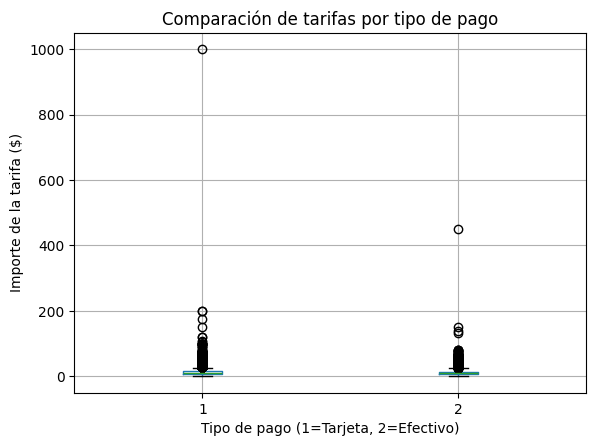

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
taxi_data[taxi_data['payment_type'].isin([1,2])].boxplot(column='fare_amount', by='payment_type')
plt.title('Comparación de tarifas por tipo de pago')
plt.suptitle('')
plt.xlabel('Tipo de pago (1=Tarjeta, 2=Efectivo)')
plt.ylabel('Importe de la tarifa ($)')
plt.show()


In [8]:
from google.colab import files
files.download('/content/Automatidata_AB_Test.ipynb')


FileNotFoundError: Cannot find file: /content/Automatidata_AB_Test.ipynb

In [9]:
# Guardar el cuaderno actual en tu carpeta Automatidata
import shutil

origen = '/content/Automatidata_AB_Test.ipynb'  # nombre del cuaderno actual
destino = '/content/drive/MyDrive/Automatidata/Automatidata_AB_Test.ipynb'

shutil.copy(origen, destino)
print("✅ Cuaderno guardado en tu carpeta Automatidata de Drive.")


FileNotFoundError: [Errno 2] No such file or directory: '/content/Automatidata_AB_Test.ipynb'

In [10]:
# Guardar el cuaderno actual en tu carpeta Automatidata
import shutil

origen = '/content/Automatidata_AB_Test.ipynb'  # nombre del cuaderno actual
destino = '/content/drive/MyDrive/Automatidata/Automatidata_AB_Test.ipynb'

shutil.copy(origen, destino)
print("✅ Cuaderno guardado en tu carpeta Automatidata de Drive.")


FileNotFoundError: [Errno 2] No such file or directory: '/content/Automatidata_AB_Test.ipynb'